<a href="https://colab.research.google.com/github/samcordner/interperability-notes-monorepo/blob/main/projects/indirect_object_verification_circuit.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
pip install transformer_lens einops matplotlib

In [1]:


import torch
import einops
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer
from transformer_lens.utils import get_act_name

device = "cuda" if torch.cuda.is_available() else "cpu"
model = HookedTransformer.from_pretrained("gpt2", device=device)
model.set_use_attn_result(True)  # needed to access per-head outputs

/tmp/ipykernel_15506/1679475045.py:5: DeprecationWarning: The 'utils' module has been deprecated. Please use 'transformer_lens.utilities' instead. Importing from utils.py will be removed in TransformerLens 4.0.
  from transformer_lens.utils import get_act_name
/tmp/ipykernel_15506/1679475045.py:8: DeprecationWarning: HookedTransformer.from_pretrained is deprecated and will be removed in a future major release. Use TransformerBridge.boot_transformers(...) instead, then call enable_compatibility_mode() for HookedTransformer-equivalent numerics. See docs/source/content/migrating_to_v3.md.
  model = HookedTransformer.from_pretrained("gpt2", device=device)


Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

Loaded pretrained model gpt2 into HookedTransformer


In [2]:
names = [(" John", " Mary"), (" Tom", " James"), (" Alice", " Bob")]
template = "When{A} and{B} went to the store,{C} gave a drink to"

clean_prompts, corrupted_prompts = [], []
clean_answers, corrupted_answers = [], []

for a, b in names:
    # clean: subject C = A (so IO = B, answer = B)
    clean_prompts.append(template.format(A=a, B=b, C=a))
    clean_answers.append(b)
    # corrupted: swap A and B in the intro, but keep C = a's *position*
    corrupted_prompts.append(template.format(A=b, B=a, C=b))
    corrupted_answers.append(a)

clean_tokens = model.to_tokens(clean_prompts)
corrupted_tokens = model.to_tokens(corrupted_prompts)

clean_answer_ids = torch.tensor(
    [model.to_single_token(a) for a in clean_answers]
)
corrupted_answer_ids = torch.tensor(
    [model.to_single_token(a) for a in corrupted_answers]
)

In [3]:
print(clean_prompts)
print(corrupted_prompts)
print(model.to_str_tokens(clean_prompts[0]))

['When John and Mary went to the store, John gave a drink to', 'When Tom and James went to the store, Tom gave a drink to', 'When Alice and Bob went to the store, Alice gave a drink to']
['When Mary and John went to the store, Mary gave a drink to', 'When James and Tom went to the store, James gave a drink to', 'When Bob and Alice went to the store, Bob gave a drink to']
['<|endoftext|>', 'When', ' John', ' and', ' Mary', ' went', ' to', ' the', ' store', ',', ' John', ' gave', ' a', ' drink', ' to']


In [4]:
def logit_diff(logits, answer_ids, other_ids):
    final_logits = logits[:, -1, :]  # last token position
    ans_logits = final_logits.gather(1, answer_ids.unsqueeze(1)).squeeze(1)
    other_logits = final_logits.gather(1, other_ids.unsqueeze(1)).squeeze(1)
    return (ans_logits - other_logits).mean()

with torch.no_grad():
    clean_logits, clean_cache = model.run_with_cache(clean_tokens)
    corrupted_logits, corrupted_cache = model.run_with_cache(corrupted_tokens)

clean_ld = logit_diff(clean_logits, clean_answer_ids, corrupted_answer_ids)
corrupted_ld = logit_diff(corrupted_logits, clean_answer_ids, corrupted_answer_ids)
print(f"Clean logit diff:     {clean_ld:.3f}")
print(f"Corrupted logit diff: {corrupted_ld:.3f}")

Clean logit diff:     3.786
Corrupted logit diff: -3.648


In [5]:
import gc

def patch_resid_hook(activation, hook, position, clean_cache):
    activation[:, position, :] = clean_cache[hook.name][:, position, :]
    return activation

n_layers = model.cfg.n_layers
seq_len = clean_tokens.shape[1]
resid_patch_results = torch.zeros(n_layers, seq_len)

model.set_use_attn_result(False)  # don't need per-head storage for this section

with torch.no_grad():
    for layer in range(n_layers):
        for position in range(seq_len):
            hook_fn = lambda act, hook, pos=position: patch_resid_hook(
                act, hook, pos, clean_cache
            )
            patched_logits = model.run_with_hooks(
                corrupted_tokens,
                fwd_hooks=[(get_act_name("resid_pre", layer), hook_fn)],
            )
            patched_ld = logit_diff(patched_logits, clean_answer_ids, corrupted_answer_ids)
            resid_patch_results[layer, position] = (patched_ld - corrupted_ld) / (
                clean_ld - corrupted_ld
            )
            del patched_logits
        gc.collect()

model.set_use_attn_result(True)  # turn back on for Section 5

In [6]:
print(resid_patch_results)

tensor([[-6.4135e-08, -6.4135e-08,  1.5126e-01, -6.4135e-08,  1.1408e+00,
         -6.4135e-08, -6.4135e-08, -6.4135e-08, -6.4135e-08, -6.4135e-08,
          8.8890e-01, -6.4135e-08, -6.4135e-08, -6.4135e-08, -6.4135e-08],
        [ 3.2067e-08, -1.9240e-07,  3.0783e-02, -2.0006e-03,  1.1801e+00,
          1.8743e-04, -2.0327e-04, -2.1036e-05,  1.4472e-04, -7.0484e-05,
          8.9325e-01,  2.0972e-04,  2.6231e-05, -6.7373e-04,  2.7530e-04],
        [-9.6202e-08,  3.8481e-07,  3.3819e-03, -4.4384e-03,  1.1693e+00,
          4.3400e-04, -1.3192e-04, -4.2906e-05,  3.9443e-05, -1.8682e-04,
          8.9104e-01, -2.8861e-04, -9.4599e-06, -8.8948e-04,  8.3019e-04],
        [ 6.4135e-08,  0.0000e+00, -5.1514e-02,  2.7919e-02,  1.1695e+00,
          5.0416e-03,  2.6199e-05, -7.8244e-05, -7.5111e-04, -1.4693e-04,
          8.9075e-01,  1.2369e-03, -8.8134e-04, -7.5111e-04,  1.5703e-04],
        [ 3.2067e-08,  3.2067e-08, -1.8737e-01,  1.6201e-01,  1.1534e+00,
          2.3468e-02, -1.8211e-04,

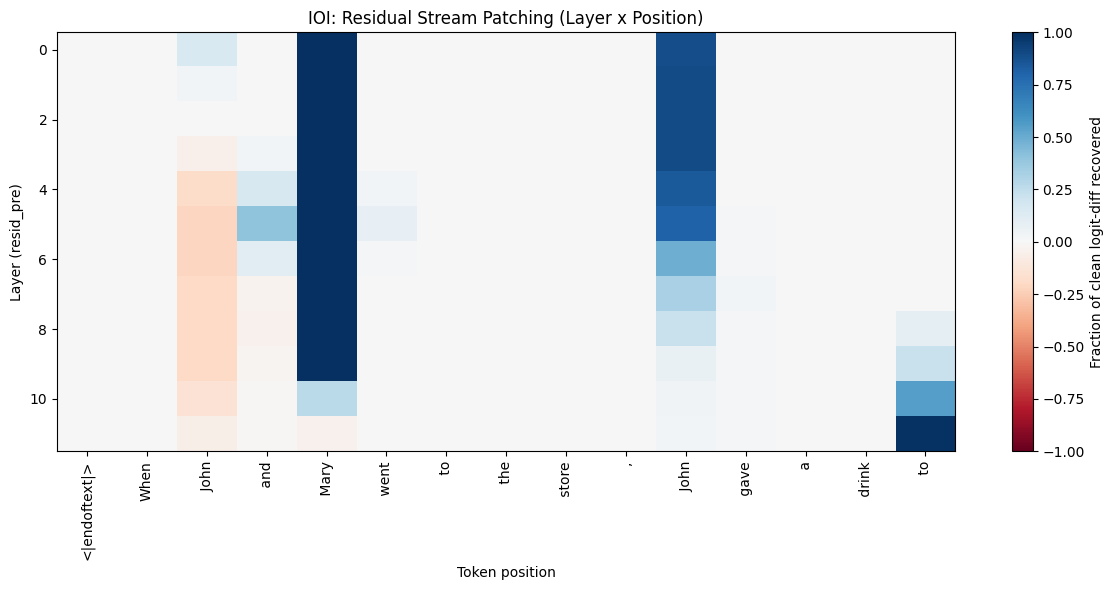

In [7]:
str_tokens = model.to_str_tokens(clean_prompts[0])
plt.figure(figsize=(12, 6))
plt.imshow(resid_patch_results.detach().numpy(), aspect="auto", cmap="RdBu", vmin=-1, vmax=1)
plt.colorbar(label="Fraction of clean logit-diff recovered")
plt.xlabel("Token position")
plt.ylabel("Layer (resid_pre)")
plt.xticks(range(seq_len), str_tokens, rotation=90)
plt.title("IOI: Residual Stream Patching (Layer x Position)")
plt.tight_layout()
plt.show()

In [8]:
n_heads = model.cfg.n_heads
head_patch_results = torch.zeros(n_layers, n_heads)

def patch_head_hook(activation, hook, head_idx, clean_cache, position=-1):
    activation[:, position, head_idx, :] = clean_cache[hook.name][:, position, head_idx, :]
    return activation

with torch.no_grad():
    for layer in range(n_layers):
        for head in range(n_heads):
            hook_fn = lambda act, hook, h=head: patch_head_hook(act, hook, h, clean_cache)
            patched_logits = model.run_with_hooks(
                corrupted_tokens,
                fwd_hooks=[(get_act_name("z", layer), hook_fn)],
            )
            patched_ld = logit_diff(patched_logits, clean_answer_ids, corrupted_answer_ids)
            head_patch_results[layer, head] = (patched_ld - corrupted_ld) / (
                clean_ld - corrupted_ld
            )
            del patched_logits
        gc.collect()

In [9]:
print(head_patch_results)

tensor([[-7.4460e-05, -1.2827e-07, -6.0639e-05, -1.3083e-05, -2.3730e-06,
         -3.3991e-06,  2.2306e-04,  2.5224e-04, -2.0331e-05,  3.9763e-06,
         -1.0646e-05, -5.8363e-06],
        [ 2.5391e-04,  1.0204e-04, -3.7583e-05, -2.0010e-05,  2.4865e-04,
         -5.6503e-05,  1.2795e-04, -2.0048e-04,  1.6435e-04, -4.6498e-05,
          8.7800e-05, -1.2798e-04],
        [-1.4539e-04, -1.5893e-04, -1.6277e-04,  1.5040e-05,  1.2699e-04,
         -8.4658e-05, -4.2784e-04, -7.5903e-05, -2.1418e-04, -1.3699e-04,
          8.7800e-05,  8.0713e-05],
        [ 1.7958e-05, -1.3956e-04, -1.9721e-05,  1.1612e-04, -4.1110e-05,
          4.0126e-04, -1.6515e-05,  1.8625e-04,  4.6498e-06, -2.0151e-04,
         -4.4028e-04, -1.2041e-04],
        [ 1.6470e-04,  1.1557e-04, -1.6749e-04, -6.7534e-05, -2.9354e-04,
         -4.9756e-04, -1.3632e-04, -7.5551e-05,  6.1069e-04, -8.7191e-05,
         -1.1640e-04, -1.0614e-05],
        [-5.1564e-05, -5.1308e-06,  7.8770e-04, -6.1184e-04,  3.3946e-04,
      

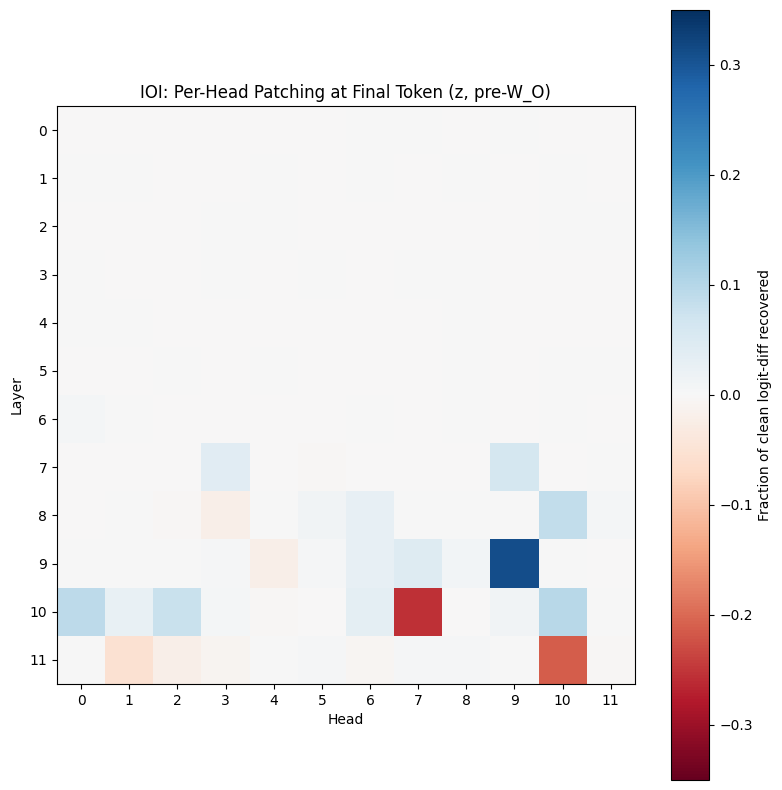

In [10]:
plt.figure(figsize=(8, 8))
plt.imshow(head_patch_results.detach().numpy(), cmap="RdBu", vmin=-0.35, vmax=0.35)
plt.colorbar(label="Fraction of clean logit-diff recovered")
plt.xlabel("Head")
plt.ylabel("Layer")
plt.xticks(range(n_heads))
plt.yticks(range(n_layers))
plt.title("IOI: Per-Head Patching at Final Token (z, pre-W_O)")
plt.tight_layout()
plt.show()